# Exp 1: epchs = 20(all else same)

# Baseline CNN on CIFAR-10 (PyTorch)

Experimenting with a baseline CNN architecture on the CIFAR-10 dataset as part of a comparative study of CNN architectures.

- **Framework:** PyTorch
- **Dataset:** CIFAR-10 (60,000 images, 10 classes)
- **Optimizer:** Adam | **Loss:** CrossEntropyLoss | **Epochs:** 10
- **Hardware:** GPU (Google Colab T4)

## 1. Importing Libraries

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preprocessing
Applying data augmentation on training set (RandomCrop, RandomHorizontalFlip) to improve generalization.
Test set uses only normalization — no augmentation.
Pixel values normalized to [-1, 1] range using mean and std of 0.5 per channel.

In [ ]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

## 3. Loading CIFAR-10 and Creating DataLoaders
Splitting training data into 80% train and 20% validation sets.
Batch size: 64, num_workers: 2 (optimized for GPU throughput).

In [ ]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 128

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [00:20<00:00, 8.43MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


In [ ]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 128

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [00:20<00:00, 8.43MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


## 4. Data Exploration
Visualizing a batch of training images to verify data loading and augmentation pipeline.

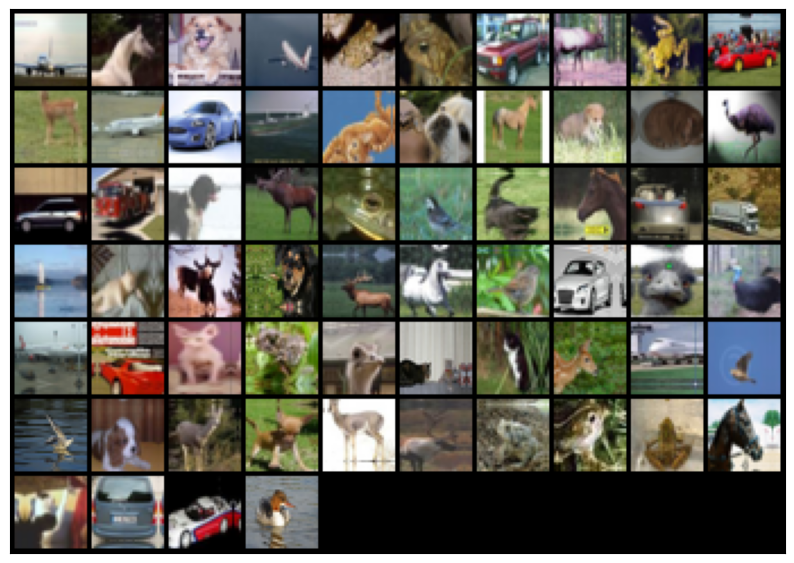

In [ ]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

## 5. Device Utilities
Helper functions and wrapper class to move data and models to GPU automatically.

In [ ]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


## 6. Model Architecture — Baseline CNN
3 Convolutional layers followed by 2 Fully Connected layers with Dropout regularization.

| Layer | Details |
|-------|---------|
| Conv1 | 3 → 32 filters, 3x3 + BN + ReLU + MaxPool |
| Conv2 | 32 → 64 filters, 3x3 + BN + ReLU + MaxPool |
| Conv3 | 64 → 128 filters, 3x3 + BN + ReLU + MaxPool |
| FC1   | 2048 → 256 + Dropout(0.3) |
| FC2   | 256 → 10 (output) |

- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout
- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout

In [ ]:
import torch.nn.functional as F
from collections import OrderedDict

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def build_model():
    return BaseCNN()

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 620,810


## 7. Training Utilities
- `accuracy()` computes batch-level classification accuracy
- `evaluate()` runs the model in eval mode over a dataloader
- `train()` runs the full training loop with OneCycleLR scheduler and gradient clipping

In [ ]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

## 8. Training
Training Baseline CNN for 10 epochs using Adam optimizer with OneCycleLR scheduler and gradient clipping (max_norm=0.1).
Weight decay of 1e-4 applied for regularization.

In [ ]:
epochs = 20
max_lr = 1e-2
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/20] | Train Loss: 1.4700 | Val Loss: 1.2331 | Val Acc: 0.5592
Epoch [2/20] | Train Loss: 1.2593 | Val Loss: 1.3940 | Val Acc: 0.5073
Epoch [3/20] | Train Loss: 1.2774 | Val Loss: 1.2858 | Val Acc: 0.5381
Epoch [4/20] | Train Loss: 1.2997 | Val Loss: 1.3157 | Val Acc: 0.5188
Epoch [5/20] | Train Loss: 1.3240 | Val Loss: 1.4707 | Val Acc: 0.4889
Epoch [6/20] | Train Loss: 1.3319 | Val Loss: 1.4153 | Val Acc: 0.5023
Epoch [7/20] | Train Loss: 1.3053 | Val Loss: 1.4407 | Val Acc: 0.4886
Epoch [8/20] | Train Loss: 1.2811 | Val Loss: 1.5610 | Val Acc: 0.4840
Epoch [9/20] | Train Loss: 1.2632 | Val Loss: 1.5201 | Val Acc: 0.4890
Epoch [10/20] | Train Loss: 1.2309 | Val Loss: 1.1467 | Val Acc: 0.5866
Epoch [11/20] | Train Loss: 1.2011 | Val Loss: 1.1896 | Val Acc: 0.5727
Epoch [12/20] | Train Loss: 1.1674 | Val Loss: 1.0836 | Val Acc: 0.6222
Epoch [13/20] | Train Loss: 1.1171 | Val Loss: 1.0336 | Val Acc: 0.6285
Epoch [14/20] | Train Loss: 1.0778 | Val Loss: 1.1388 | Val Acc: 0.5974
E

## 9. Training Curves
Plotting validation accuracy, train/val loss, and learning rate schedule across epochs.

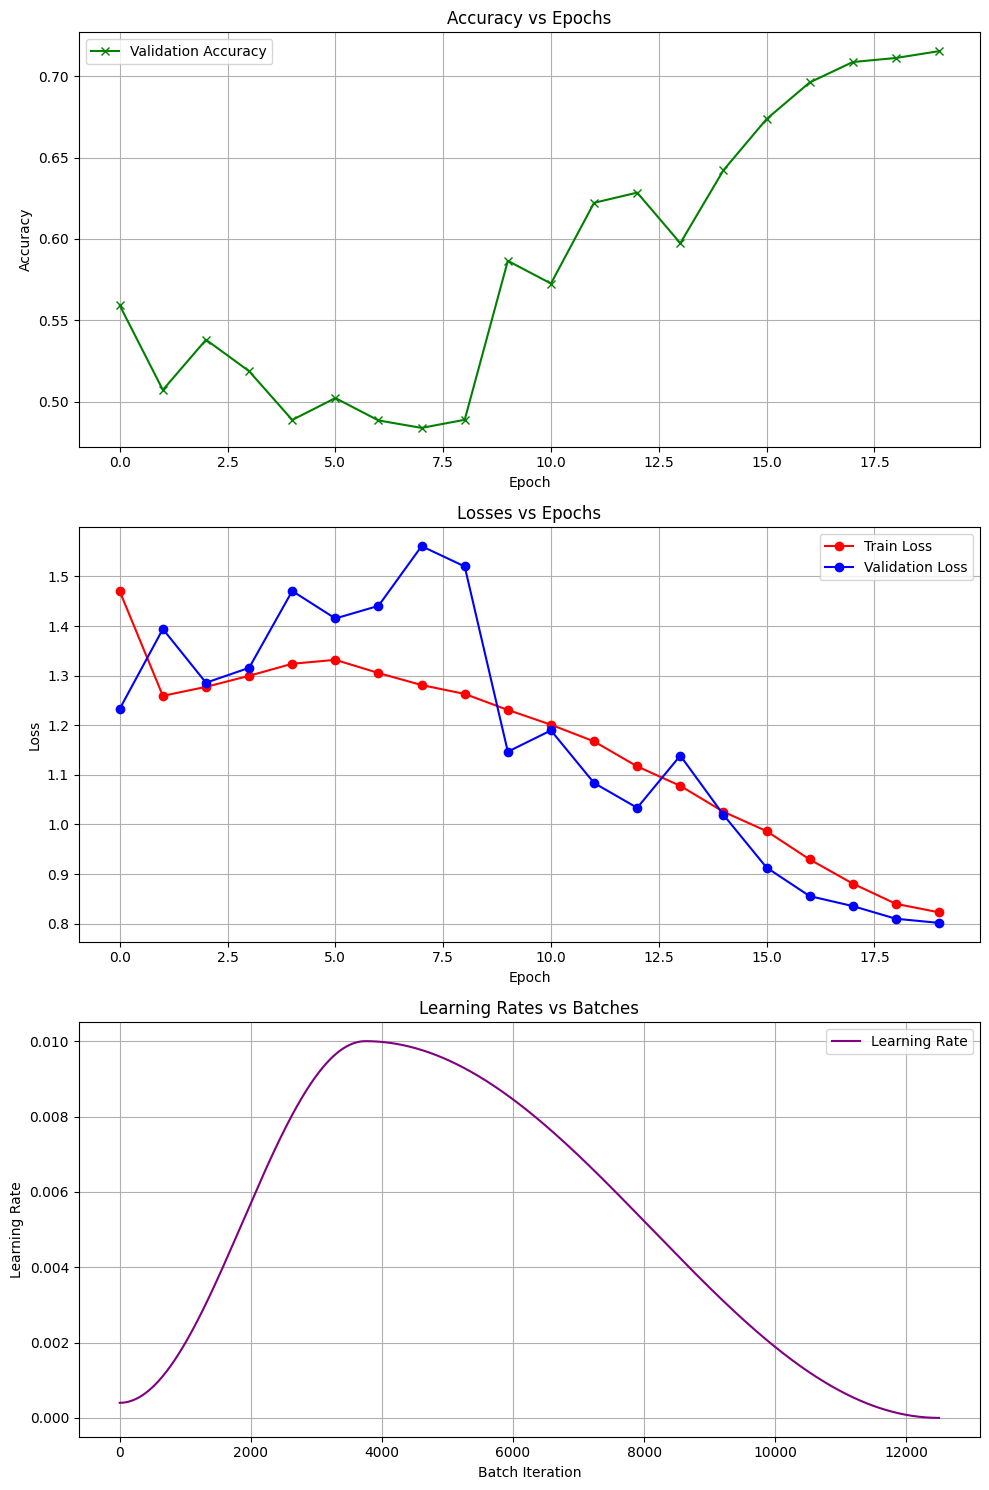

In [ ]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

## 10. Saving and Evaluating the Model
Saving trained weights, then verifying the save/load pipeline by evaluating both the original and reloaded model.
Both should produce identical test accuracy.

In [ ]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_baseline_cnn.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_baseline_cnn.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.7480
Reloaded model test accuracy: 0.7480


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *74.80%* |
| Trainable Parameters | *620,810* |
| Training Time | *576.44 seconds(9.60733333 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 20 |
| Optimizer | Adam + OneCycleLR |

**Observation:** Accuracy improved by 0.64%. Warmup phase extended to epoch 5 causing a large accuracy dip and validation loss spike at that point. Model recovered and improved consistently from epoch 7.5. More epochs help but with diminishing returns.

# Exp 2: batchsize = 128 (all else same)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

In [ ]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 128

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 128


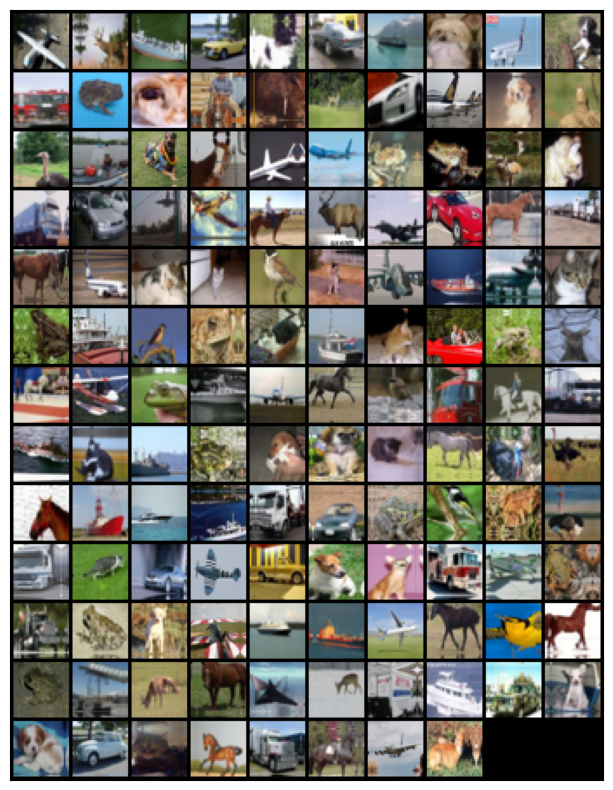

In [ ]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

In [ ]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


In [ ]:
import torch.nn.functional as F
from collections import OrderedDict

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def build_model():
    return BaseCNN()

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 620,810


In [ ]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

In [ ]:
epochs = 10
max_lr = 1e-2
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 1.5324 | Val Loss: 1.3992 | Val Acc: 0.5144
Epoch [2/10] | Train Loss: 1.3189 | Val Loss: 1.3356 | Val Acc: 0.5257
Epoch [3/10] | Train Loss: 1.2950 | Val Loss: 1.4951 | Val Acc: 0.4788
Epoch [4/10] | Train Loss: 1.2350 | Val Loss: 1.7478 | Val Acc: 0.4085
Epoch [5/10] | Train Loss: 1.1689 | Val Loss: 1.3139 | Val Acc: 0.5286
Epoch [6/10] | Train Loss: 1.0940 | Val Loss: 1.2256 | Val Acc: 0.5817
Epoch [7/10] | Train Loss: 1.0000 | Val Loss: 1.1054 | Val Acc: 0.6104
Epoch [8/10] | Train Loss: 0.9109 | Val Loss: 0.8617 | Val Acc: 0.6968
Epoch [9/10] | Train Loss: 0.8046 | Val Loss: 0.7479 | Val Acc: 0.7341
Epoch [10/10] | Train Loss: 0.7280 | Val Loss: 0.7065 | Val Acc: 0.7545

Training complete. Training Time: 272.32 seconds


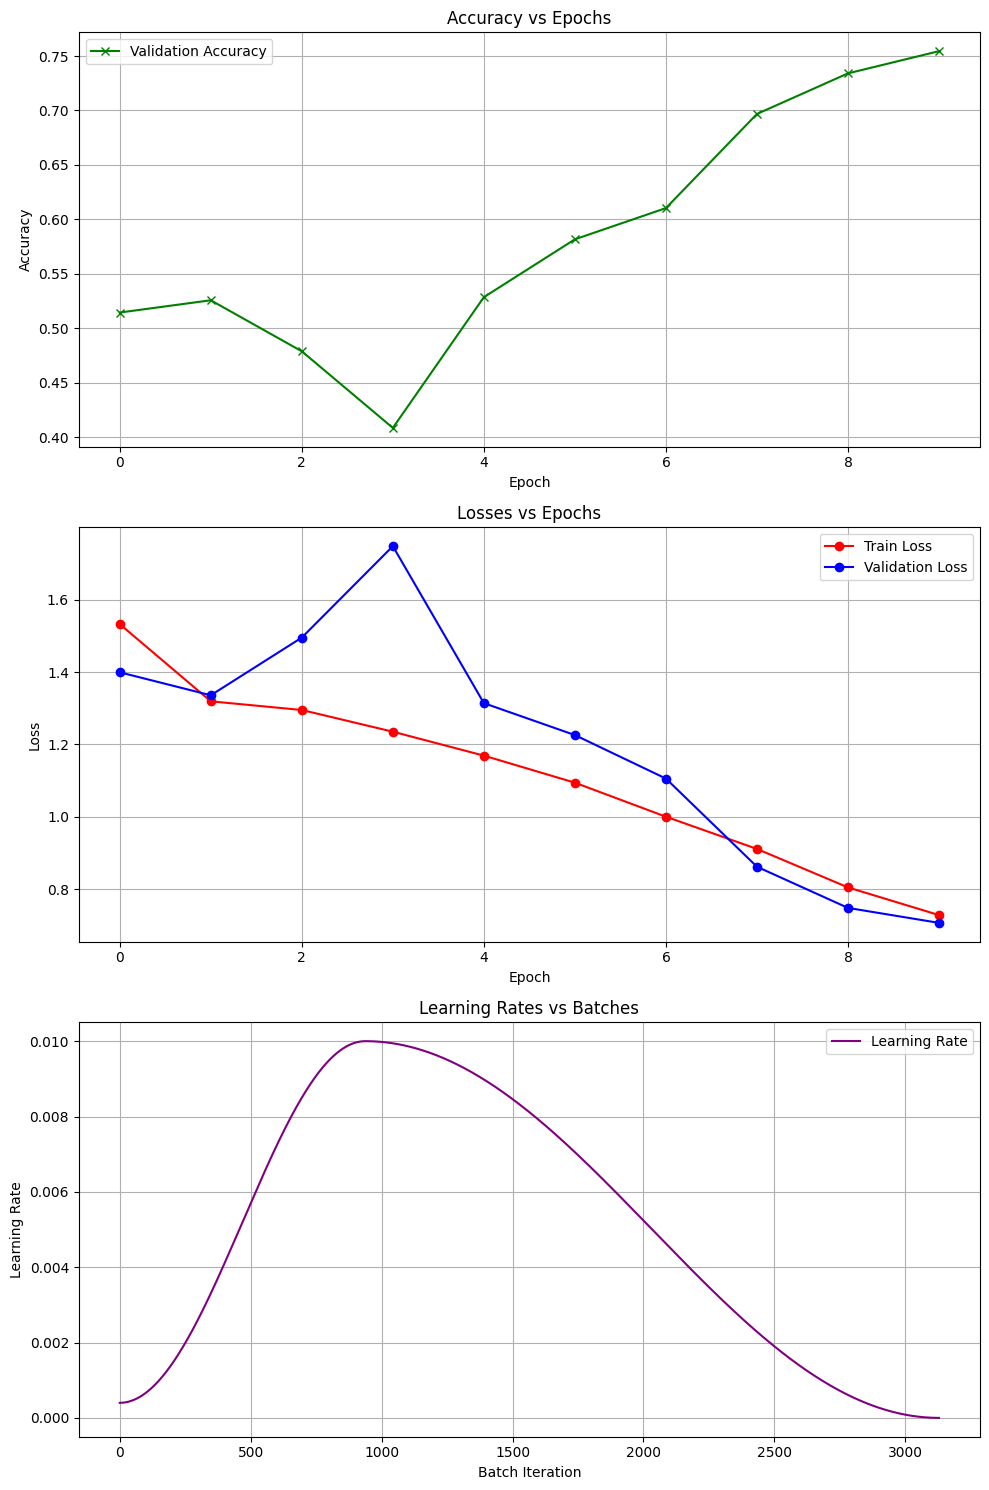

In [ ]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

In [ ]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_baseline_cnn.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_baseline_cnn.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.7764
Reloaded model test accuracy: 0.7764


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *77.64%* |
| Trainable Parameters | *620,810* |
| Training Time | *272.32 seconds(4.53866667)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** Increasing batch size from 64 to 128 improved accuracy
by 3.48% (74.16% → 77.64%), the best result so far.

With larger batches the model sees more images before
updating weights, giving a smoother and more accurate
estimate of the true gradient. This provides better
direction for weight updates compared to the noisier
estimates from smaller batches, resulting in more stable
training and improved accuracy.

Training time increased slightly from 254.05s to 272.32s
due to the larger batch size requiring more memory
operations per step.

# Exp 3: lr = 0.001 (all else are same)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

In [ ]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [00:05<00:00, 33.6MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


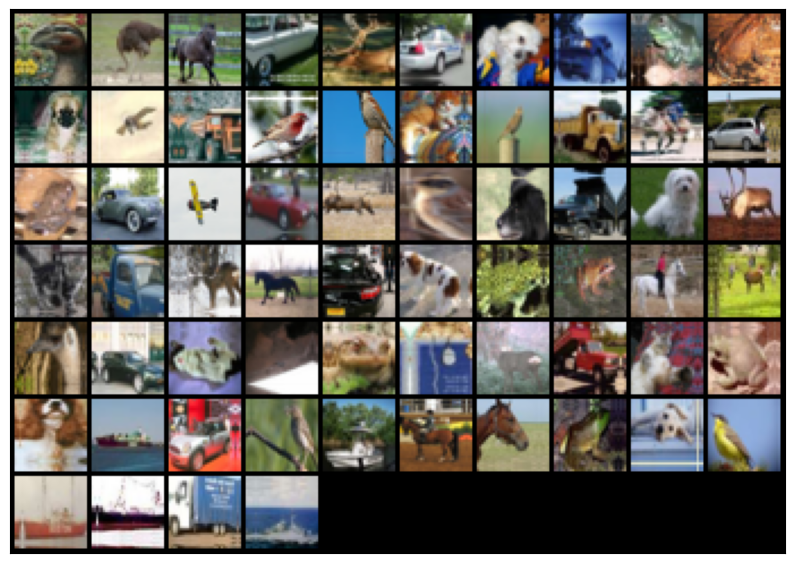

In [ ]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

In [ ]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


In [ ]:
import torch.nn.functional as F
from collections import OrderedDict

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def build_model():
    return BaseCNN()

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 620,810


In [ ]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

In [ ]:
epochs = 10
max_lr = 0.001
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 1.6984 | Val Loss: 1.3450 | Val Acc: 0.5126
Epoch [2/10] | Train Loss: 1.2839 | Val Loss: 1.1354 | Val Acc: 0.5939
Epoch [3/10] | Train Loss: 1.1353 | Val Loss: 1.1236 | Val Acc: 0.5946
Epoch [4/10] | Train Loss: 1.0448 | Val Loss: 1.3718 | Val Acc: 0.5352
Epoch [5/10] | Train Loss: 0.9730 | Val Loss: 0.9293 | Val Acc: 0.6735
Epoch [6/10] | Train Loss: 0.9049 | Val Loss: 0.8872 | Val Acc: 0.6852
Epoch [7/10] | Train Loss: 0.8294 | Val Loss: 0.7865 | Val Acc: 0.7261
Epoch [8/10] | Train Loss: 0.7642 | Val Loss: 0.7286 | Val Acc: 0.7486
Epoch [9/10] | Train Loss: 0.6998 | Val Loss: 0.6792 | Val Acc: 0.7625
Epoch [10/10] | Train Loss: 0.6607 | Val Loss: 0.6621 | Val Acc: 0.7663

Training complete. Training Time: 252.69 seconds


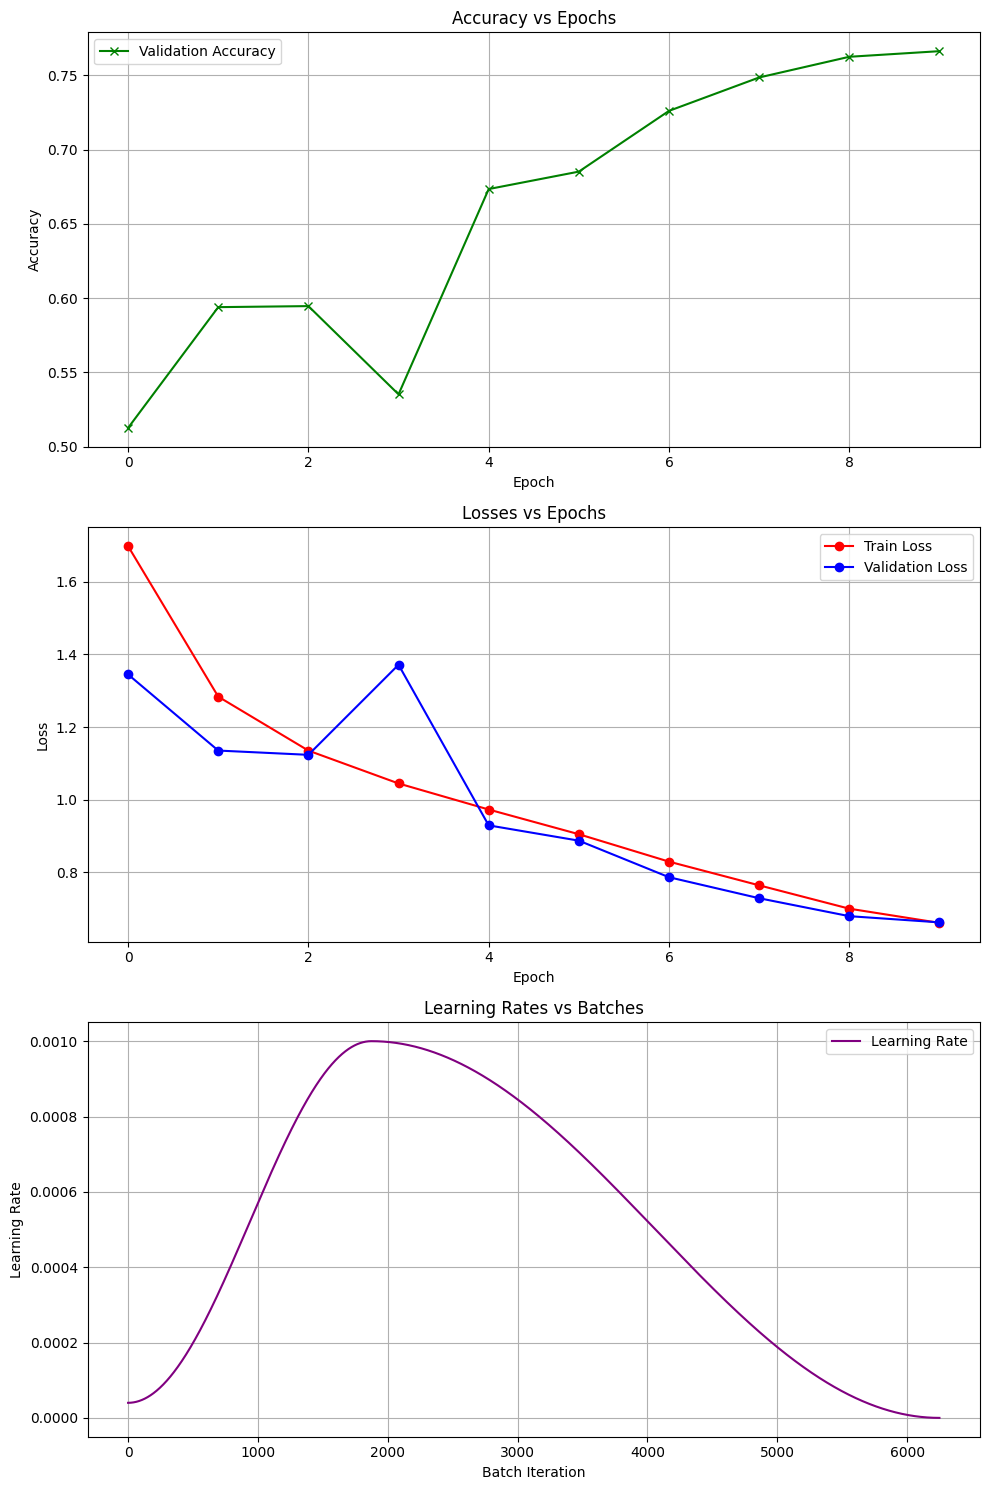

In [ ]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

In [ ]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_baseline_cnn.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_baseline_cnn.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.8029
Reloaded model test accuracy: 0.8029


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *80.29%* |
| Trainable Parameters | *620,810*
|Training Time|252.69 seconds(4.2115 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** Reducing learning rate from 0.01 to 0.001 improved
accuracy by 5.02% (74.16% → 80.29%), the best result
so far.

With max_lr=0.01 the OneCycleLR warmup caused aggressive
updates that overshot the optimal solution, leading to
unstable training in early epochs. Reducing to 0.001
lowered the peak learning rate, resulting in smaller
more precise weight updates and more stable training
throughout all epochs.

Note: Learning rate cannot be reduced indefinitely —
too small a value means the model takes extremely tiny
steps and may never reach good accuracy within limited
epochs. 0.001 appears to be a better sweet spot for
this architecture and dataset.

# Exp 4: dropout = 0.5 (all else are same)

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

In [3]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


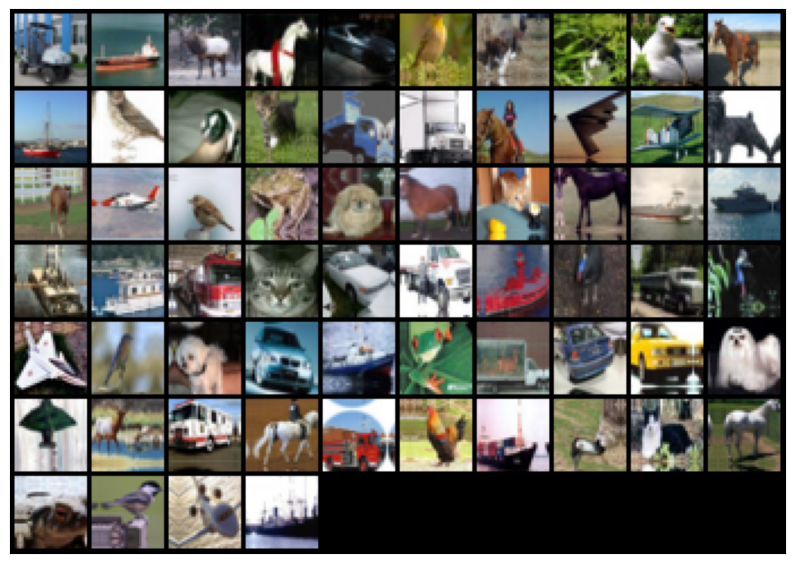

In [4]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

In [5]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


In [6]:
import torch.nn.functional as F
from collections import OrderedDict

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def build_model():
    return BaseCNN()

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 620,810


In [7]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

In [8]:
epochs = 10
max_lr = 0.01
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 1.6122 | Val Loss: 1.5423 | Val Acc: 0.4488
Epoch [2/10] | Train Loss: 1.4951 | Val Loss: 1.4928 | Val Acc: 0.4644
Epoch [3/10] | Train Loss: 1.4896 | Val Loss: 1.4841 | Val Acc: 0.4656
Epoch [4/10] | Train Loss: 1.4298 | Val Loss: 1.6333 | Val Acc: 0.4546
Epoch [5/10] | Train Loss: 1.3713 | Val Loss: 1.2293 | Val Acc: 0.5666
Epoch [6/10] | Train Loss: 1.3017 | Val Loss: 1.2774 | Val Acc: 0.5474
Epoch [7/10] | Train Loss: 1.2191 | Val Loss: 1.4689 | Val Acc: 0.4866
Epoch [8/10] | Train Loss: 1.1140 | Val Loss: 0.9717 | Val Acc: 0.6581
Epoch [9/10] | Train Loss: 1.0173 | Val Loss: 0.8746 | Val Acc: 0.6892
Epoch [10/10] | Train Loss: 0.9523 | Val Loss: 0.8500 | Val Acc: 0.6952

Training complete. Training Time: 253.54 seconds


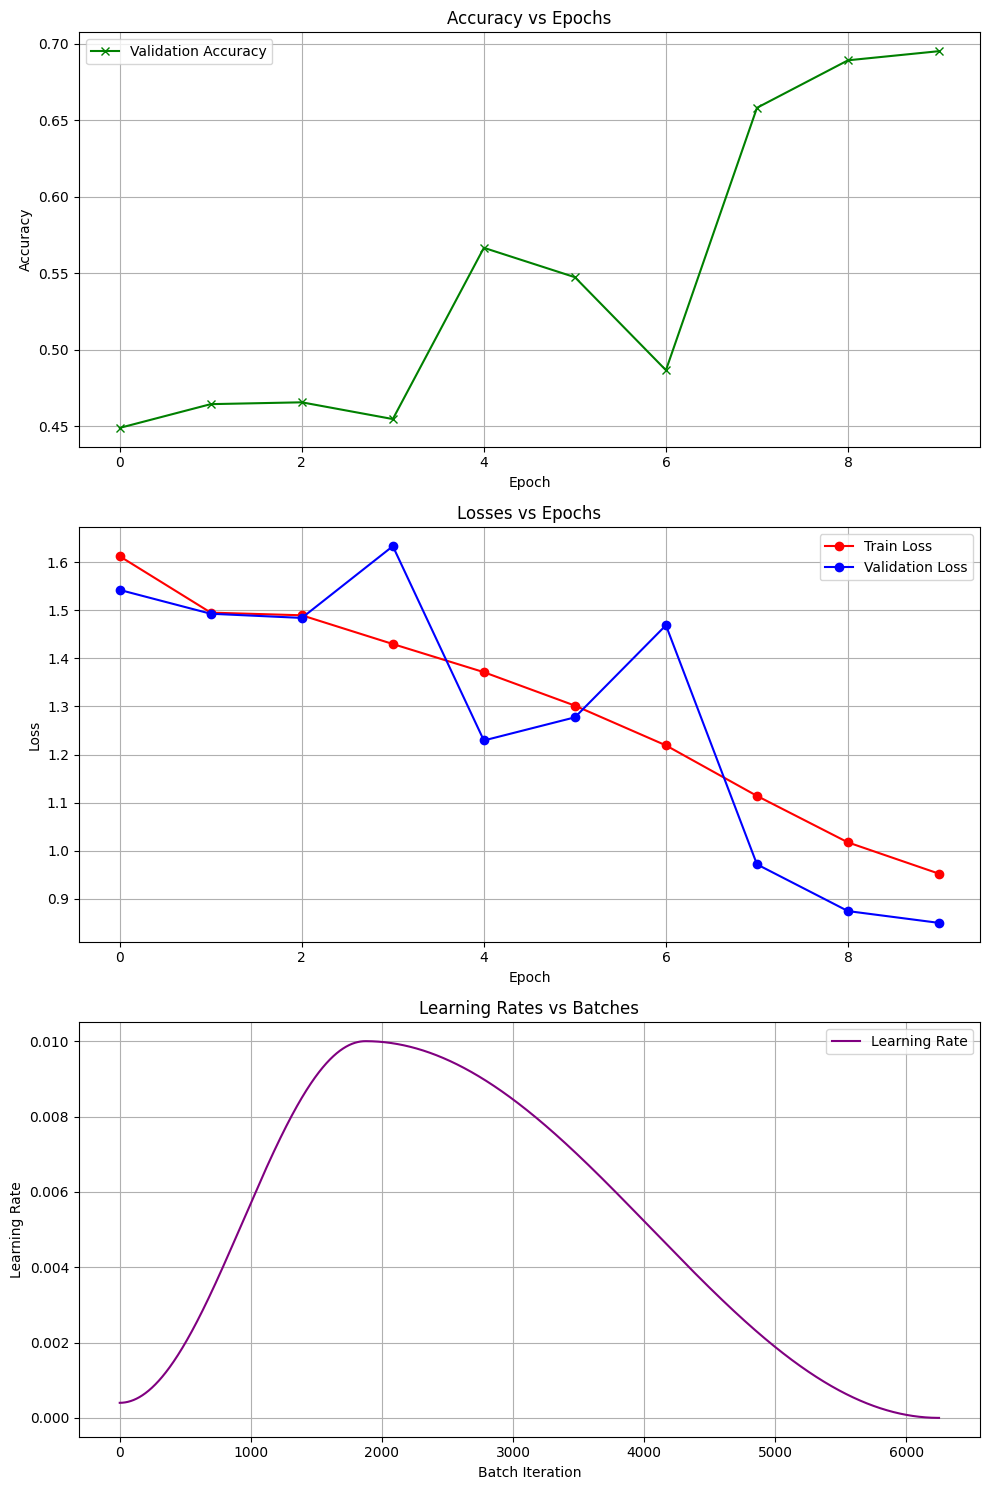

In [9]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

In [10]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_baseline_cnn.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_baseline_cnn.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.7161
Reloaded model test accuracy: 0.7161


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *71.61%* |
| Trainable Parameters | *620,810*|
|Training Time|253.54 seconds(4.22566667 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** Increasing dropout from 0.3 to 0.5 reduced accuracy
by 2.55% (74.16% → 71.61%), performing worse than baseline.

With dropout=0.5, 50% of neurons are randomly disabled
during each training step. For a small shallow network
like the Baseline CNN with only 620,810 parameters,
this is too aggressive — the remaining 50% of active
neurons do not have enough capacity to learn meaningful
patterns from the images.

Dropout=0.3 is a better fit for this architecture —
disabling only 30% of neurons provides enough
regularization to prevent overfitting while preserving
sufficient learning capacity.